In [62]:
from xaikd import models, datasets, utils, attributors, logit_modifiers
from torch import nn
import numpy as np 

from collections import OrderedDict
from matplotlib import pyplot as plt

In [63]:
DEVICE = utils.get_device()

In [64]:
dataset = datasets.construct("celeba-attr6")

In [65]:
dl_train = datasets.build_dataloader(
    dataset.create_subset(train_split=True), 
    shuffle=False
)

In [66]:
model = nn.Sequential(
    OrderedDict(
        [
            ("base", models.get_trained_model("celeba-resnet18-finetunedv1")),
            ("layer_task_logit",  models.layers.TaskLogitSelection(task_id=dataset.attr_ix)),
        ]
    )
)
model.eval()
model.to(DEVICE)

Sequential(
  (base): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_run

In [67]:
LAYER = "base.layer4"

In [68]:
rng = np.random.default_rng(seed=1)

arr_logodd, arr_act, arr_ctx = attributors.extract_activation_grad(
    model=model,
    layer=LAYER,
    dataloader=dl_train,
    logit_modifier= logit_modifiers.BinaryLogOddWinning(threshold=0),
    device=DEVICE,
    rng=rng,
)

extract act-grad at layer=base.layer4:   0%|          | 0/2544 [00:08<?, ?it/s]

> shape(arr_act)=(162770, 512, 20); shape(arr_logits)=(162770,)


vmin=0.00017164435775426928, vmax=2.013741966686857


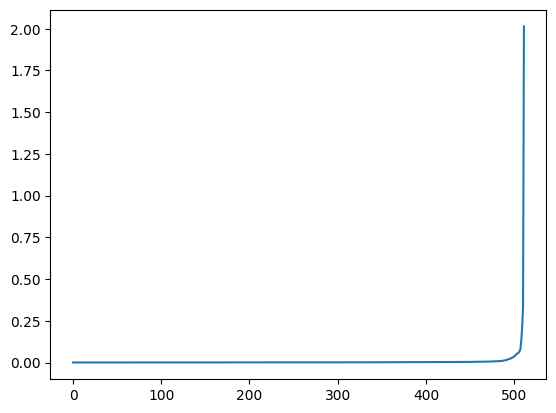

In [70]:
def goodone(arr_act, arr_ctx):
    arr_act = utils.flatten_3d_tensor(arr_act)

    
    arr_ctx = utils.flatten_3d_tensor(arr_ctx)

    N, _ = arr_act.shape
    
    mean_act = np.mean(arr_act, axis=0)
    mean_ctx = np.mean(arr_ctx, axis=0)

    arr_act_centered = arr_act - mean_act[None,:]
    
    cov_a = (arr_act_centered).T @ (arr_act_centered)
    tr_a = np.trace(cov_a)

    cov_c = (arr_ctx.T @ arr_ctx) / N
    tr_c = np.trace(cov_c)

    cov_ac = (arr_act_centered.T @ arr_ctx) / N 

 
    cov_acca = cov_ac + cov_ac.T

    coef_acca = 1 / np.sqrt(tr_a * tr_c)
    coef_a = 2 / tr_a
    coef_c = 2 / tr_c 
    cov = coef_acca * cov_acca + coef_a * cov_a  + coef_c * cov_c

    eigvals, _ = np.linalg.eigh(cov)

    vmin = np.min(eigvals)
    vmax = np.max(eigvals)
    
    plt.plot(eigvals)
    print(f"vmin={vmin}, vmax={vmax}")
    
goodone(arr_act, arr_ctx)

Coefficients: coeff_acca: 1.2878e-03, coeff_a: 5.3781e-10, coeff_c: 1.2335e+04
vmin=0.0001716121997266361, vmax=2.01374679572386


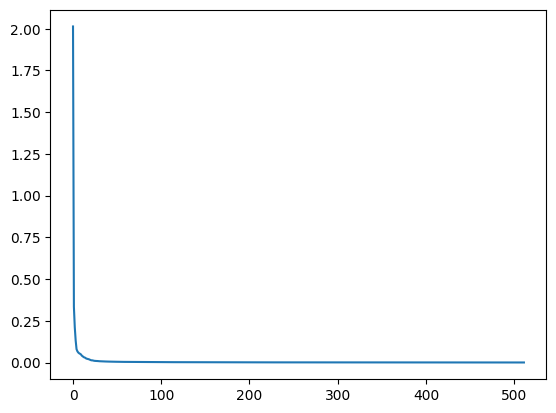

In [77]:
def bad(arr_act, arr_ctx):
    arr_act = utils.flatten_3d_tensor(arr_act)

    mean_act = np.mean(arr_act, axis=0)
    
    arr_ctx = utils.flatten_3d_tensor(arr_ctx)
    mean_ctx = np.mean(arr_ctx, axis=0)

    N, _ = arr_act.shape


    uncen_cov_a = N* ((arr_act.T @ arr_act) / N).astype(np.longdouble)
    outer_mean_a = N * np.outer(mean_act, mean_act).astype(np.longdouble)
    cov_a =  uncen_cov_a - outer_mean_a
    tr_a = np.trace(cov_a)

    cov_c = (arr_ctx.T @ arr_ctx) / N
    cov_c = cov_c.astype(np.longdouble)
    tr_c = np.trace(cov_c)

    
    cov_ac = ((arr_act.T @ arr_ctx) / N).astype(np.longdouble) - np.outer(mean_act, mean_ctx).astype(np.longdouble)
    cov_acca = cov_ac + cov_ac.T

    # Remark: these coefficients are more stable than the one written in the paper.
    # They are the ones in the paper devided by 1/sqrt(tr_a*tr_c).
    coef_acca = 1 / np.sqrt(tr_a * tr_c)
    coef_a = 2 / tr_a
    coef_c = 2 / tr_c

    print(
        f"Coefficients: coeff_acca: {coef_acca:.4e}, coeff_a: {coef_a:.4e}, coeff_c: {coef_c:.4e}"
    )

    cov_pos_def = coef_acca * cov_acca + coef_a * cov_a + coef_c * cov_c
    cov_pos_def = cov_pos_def.astype(np.float64)
    
    eigvals, eigvecs = utils.solve_eigh(cov_pos_def)

    # assert (eigvals >= 0).all()


    vmin = np.min(eigvals)
    vmax = np.max(eigvals)
    
    plt.plot(eigvals)
    print(f"vmin={vmin}, vmax={vmax}")
    
bad(arr_act, arr_ctx)